# Phase and the Bloch Sphere

This notebook visualises single- and two-qubit states on the **Bloch sphere** and shows how different gates rotate the qubit's "arrow".

### What changed since the original notebook?

| Old API | New API |
|---|---|
| `from qiskit.tools.visualization import plot_bloch_multivector` | `from qiskit.visualization import plot_bloch_multivector` |
| `Aer.get_backend("statevector_simulator")` | `Statevector(circuit)` (from `qiskit.quantum_info`) |
| `Aer.get_backend("qasm_simulator")` | `AerSimulator()` (from `qiskit_aer`) |
| `execute(circuit, backend=...)` | `transpile(...)` + `simulator.run(...)` |

We compute the **statevector** purely from the circuit description (no separate simulator needed) and use a single `AerSimulator` for the sampling.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit_aer import AerSimulator
import math

%matplotlib inline

## What simulators are available?

In the old API you would call `Aer.backends()` to see all named simulators (`qasm_simulator`, `statevector_simulator`, `unitary_simulator`, …). Now there is a single `AerSimulator` class that can switch between simulation **methods**.

In [2]:
# In modern Qiskit there is no longer a top-level `Aer` object that lists
# named back-ends ('qasm_simulator', 'statevector_simulator', ...). Everything
# is now done through a single `AerSimulator`, which can switch between
# different *methods* (statevector, density matrix, MPS, ...).
print("Available simulation methods:", AerSimulator().available_methods())

Available simulation methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')


In [3]:
# Modern equivalent: a single AerSimulator handles measurement-style sampling,
# and `Statevector(circuit)` from qiskit.quantum_info gives us the full
# wavefunction (the old `statevector_simulator`).
simulator = AerSimulator()

## A helper that returns *both* a statevector and counts

For every circuit in this notebook we want to see two things:

1. The full **statevector** (so we can plot it on the Bloch sphere).
2. The **measurement counts** (so we can see what an actual run would give).

The function below does both. Note that we *don't* mutate the input circuit – we add measurements only on a copy. That way the same `circuit` object can grow gate by gate across cells without accumulating measurement instructions.

In [4]:
def run_on_simulators(circuit):
    """Return (statevector, counts) for `circuit`.

    The circuit must NOT contain measurements – we add a fresh copy with
    measurements only for the sampling step. This keeps the original
    `circuit` clean so it can be re-used in later cells.
    """
    # Statevector before any measurement (measurement collapses the state).
    statevec = Statevector(circuit)

    # Add measurements to a copy and sample 1024 shots.
    measured = circuit.copy()
    num_qubits = circuit.num_qubits
    measured.measure(range(num_qubits), range(num_qubits))

    compiled = transpile(measured, simulator)
    counts = simulator.run(compiled, shots=1024).result().get_counts()

    return statevec, counts

## The starting point – |00⟩

Let's begin with an empty 2-qubit circuit. Both qubits sit in |0⟩, which on the Bloch sphere means an arrow pointing **straight up** (north pole).

In [5]:
circuit = QuantumCircuit(2,2)
statevec, counts = run_on_simulators(circuit)

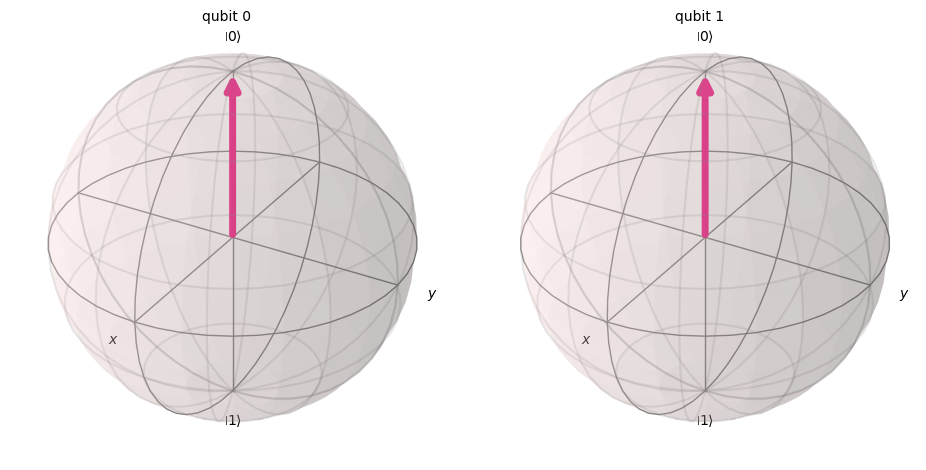

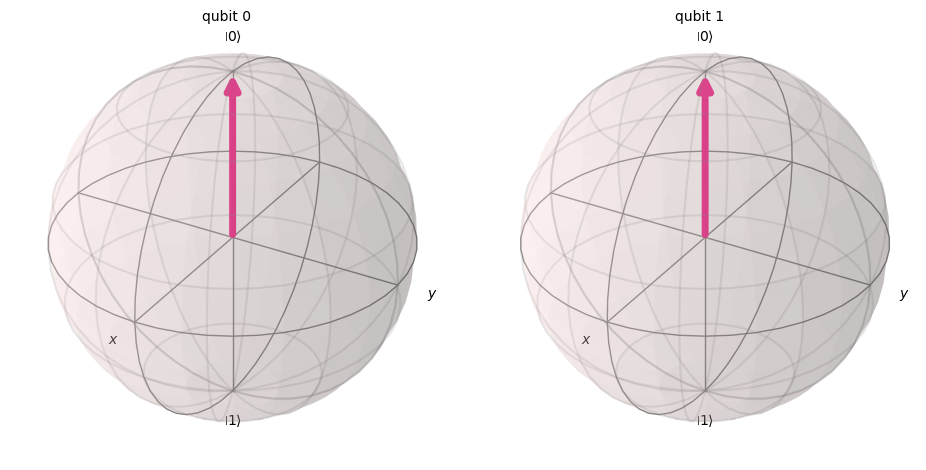

In [6]:
plot_bloch_multivector(statevec)

## Adding a Hadamard on qubit 0

Now we put qubit 0 into superposition. On its Bloch sphere the arrow moves from the north pole to the equator, while qubit 1 still sits at the top.

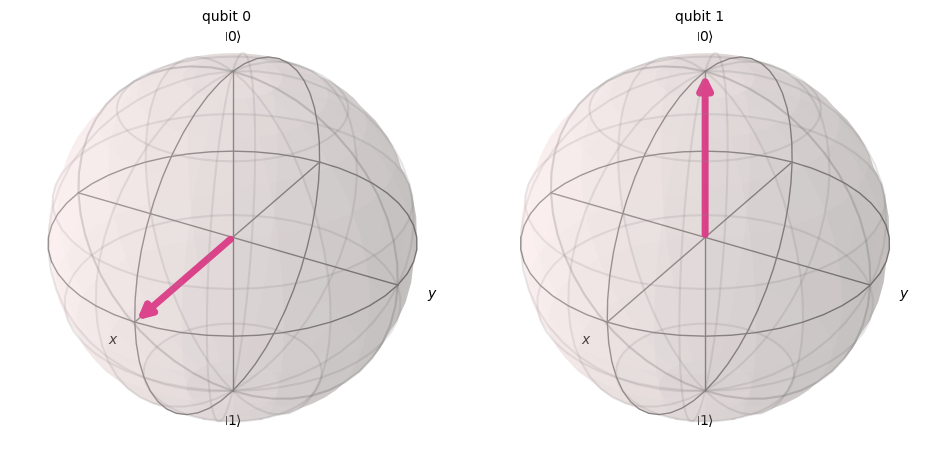

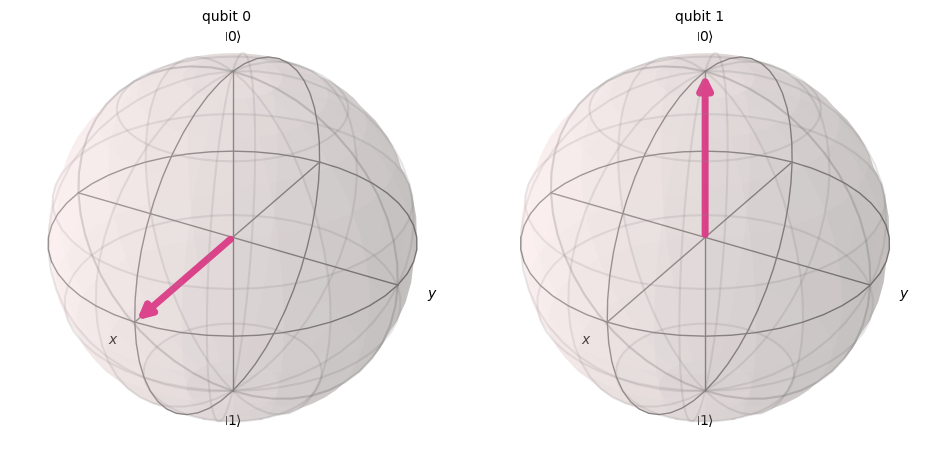

In [7]:
circuit.h(0)
statevec, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevec)

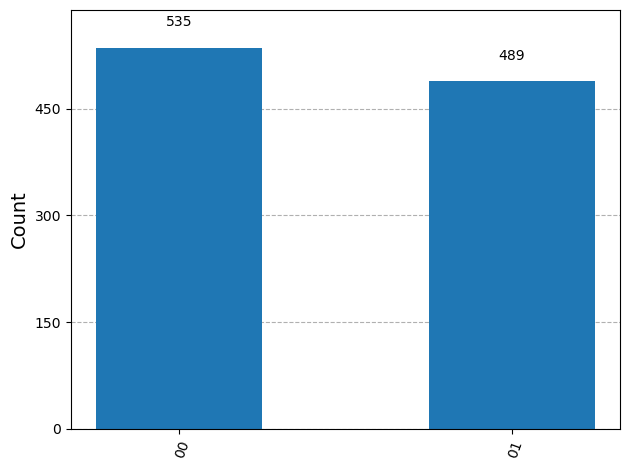

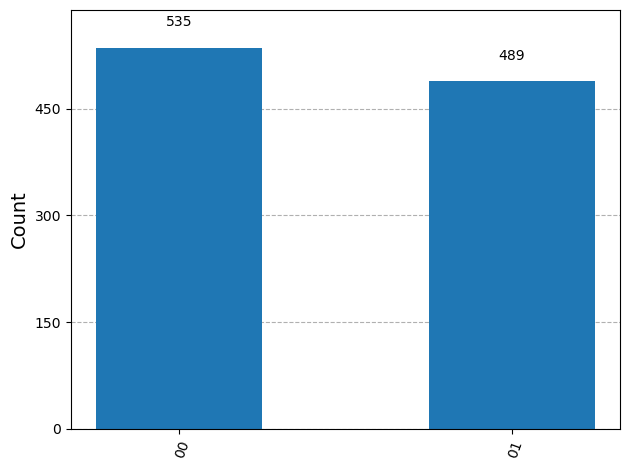

In [8]:
plot_histogram([counts])

## A Bell state on the Bloch sphere

When the two qubits are **entangled** (Bell state), neither qubit on its own has a definite Bloch vector. Each individual Bloch sphere collapses to the centre – there's no arrow to draw – which is precisely what entanglement means: the joint state cannot be written as a product of two single-qubit states.

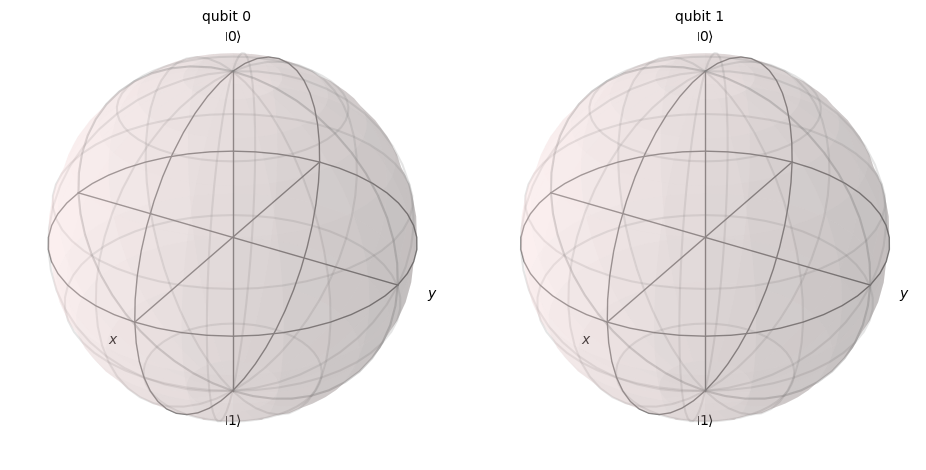

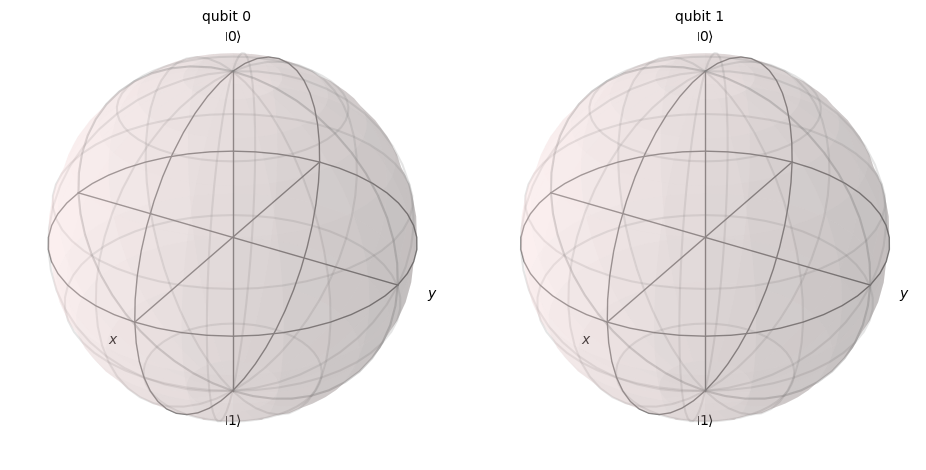

In [9]:
circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1)
statevec, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevec)

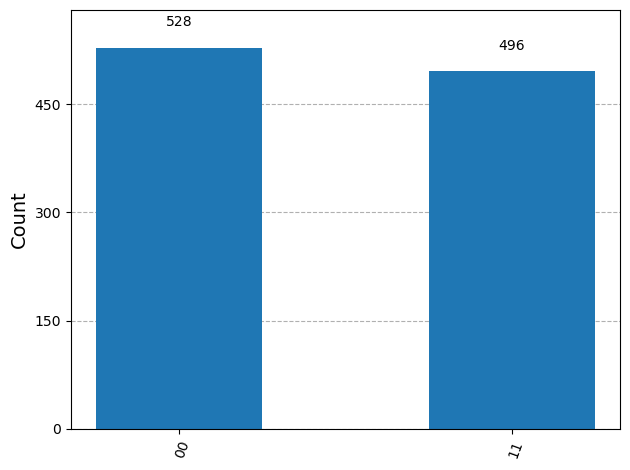

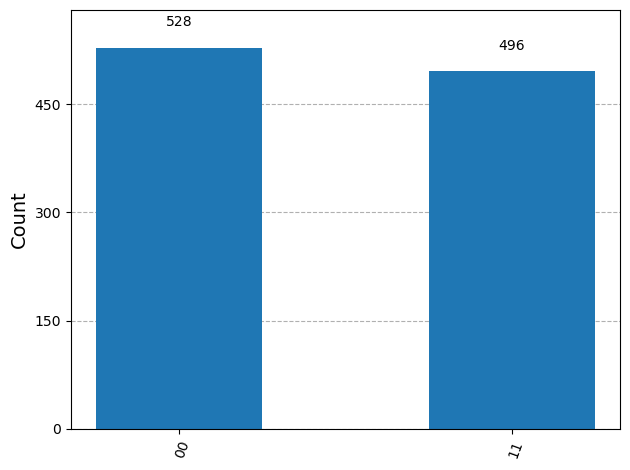

In [10]:
plot_histogram([counts])

## Continuous rotations – `rx`, `ry`, `rz`

Most quantum operations are *continuous* rotations of the Bloch vector. `rx(θ)` rotates around the **X** axis by an angle θ. Try different angles and watch the arrow move on the Bloch sphere.

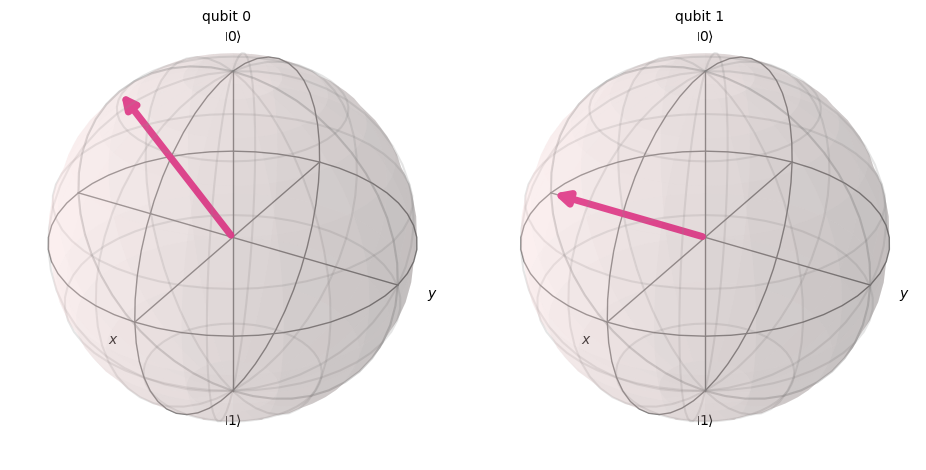

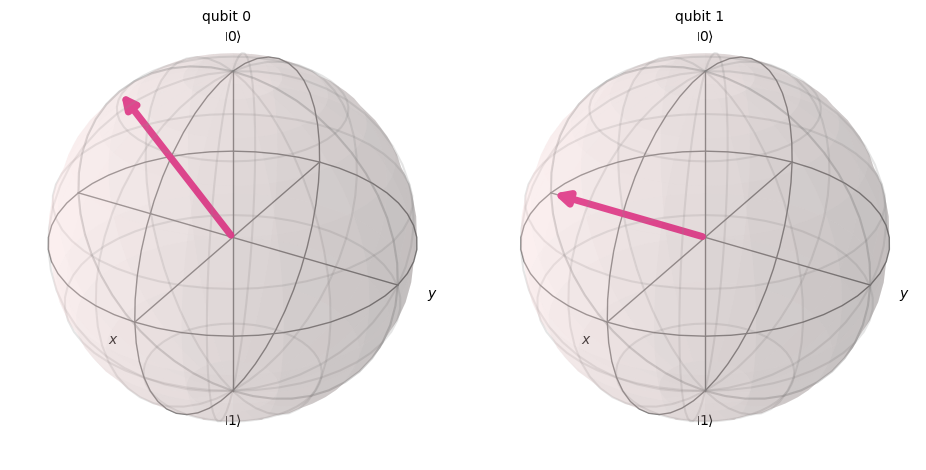

In [11]:
circuit = QuantumCircuit(2,2)
circuit.rx(math.pi/4, 0)
circuit.rx(math.pi/2, 1)
statevec, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevec)

### `ry` – rotation about the Y axis

The same idea, but around the Y axis. `ry(π/2)` takes |0⟩ to the **+x** axis (which is what the Hadamard gate does, up to a phase).

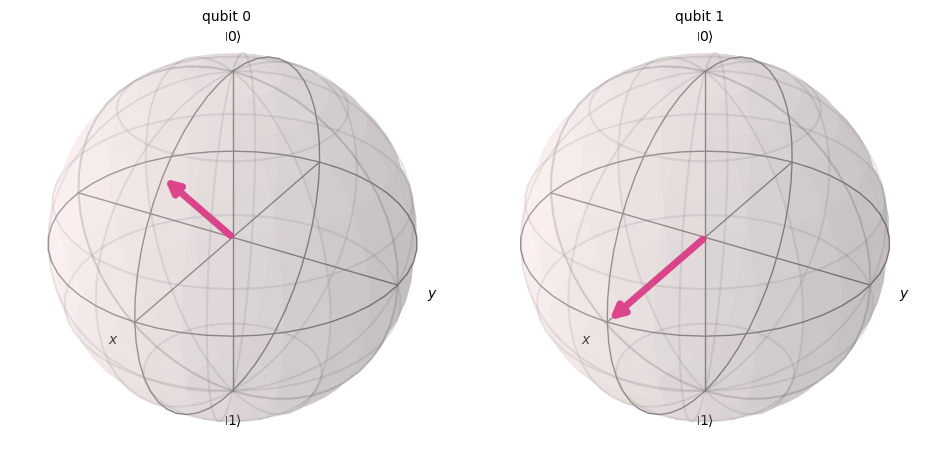

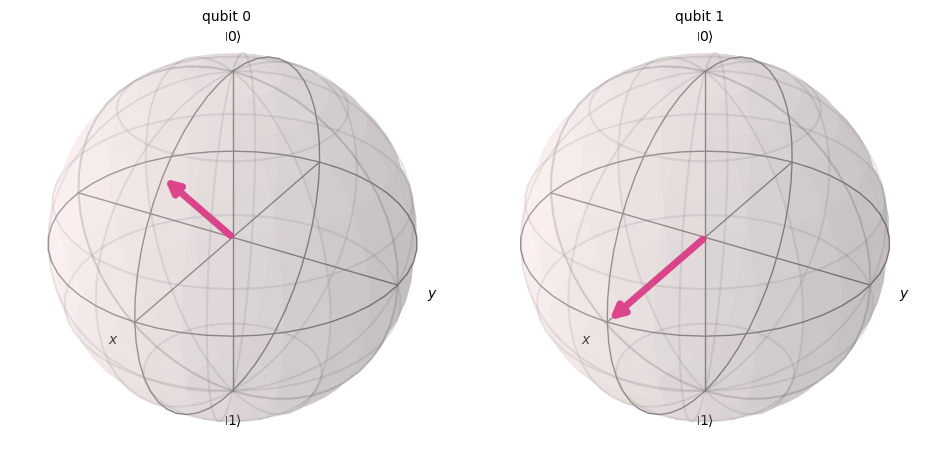

In [12]:
circuit = QuantumCircuit(2,2)
circuit.ry(math.pi/4, 0)
circuit.ry(math.pi/2, 1)
statevec, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevec)

## A single qubit in superposition

Now we strip everything down to **one qubit** so the Bloch sphere is easy to read. After a single Hadamard the qubit lies on the equator of the sphere, on the **+x** axis.

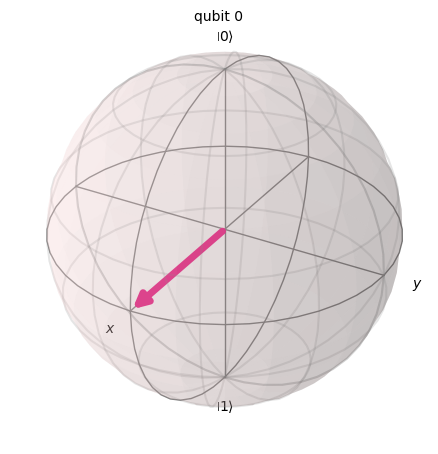

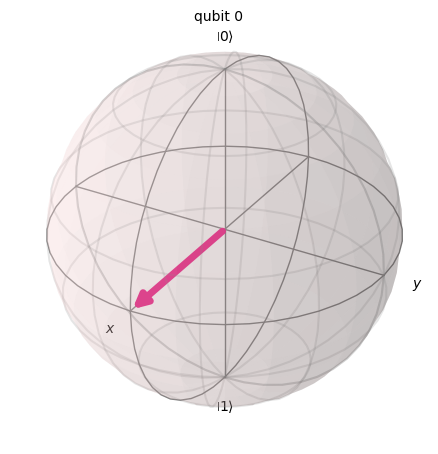

In [13]:
circuit = QuantumCircuit(1,1)
circuit.h(0)
statevec, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevec)

### Z gate – flipping the phase

After `H`, the state is `(|0⟩ + |1⟩) / √2`. Applying `Z` then flips the sign of `|1⟩`, giving `(|0⟩ - |1⟩) / √2`. On the Bloch sphere the qubit moves from the **+x** axis to the **−x** axis. Importantly, the *measurement* histogram does not change (still 50/50) – this is the famous "phase is invisible to a measurement in the computational basis".

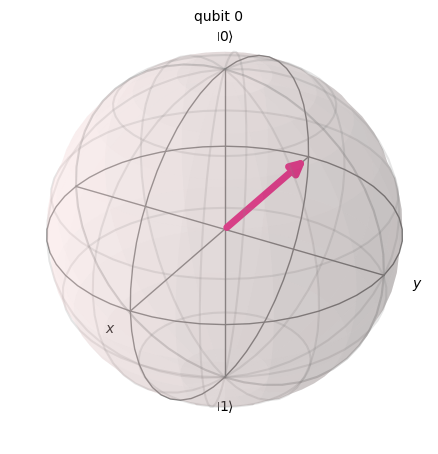

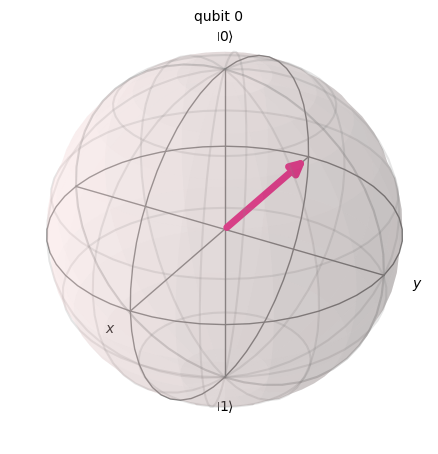

In [14]:
circuit = QuantumCircuit(1,1)
circuit.h(0)
circuit.z(0)
statevec, counts = run_on_simulators(circuit)
plot_bloch_multivector(statevec)

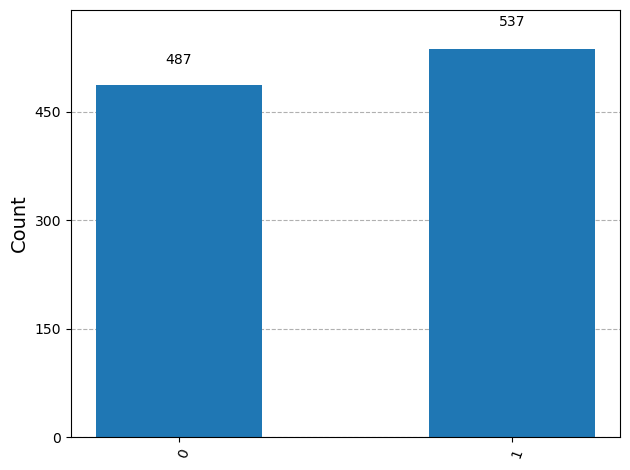

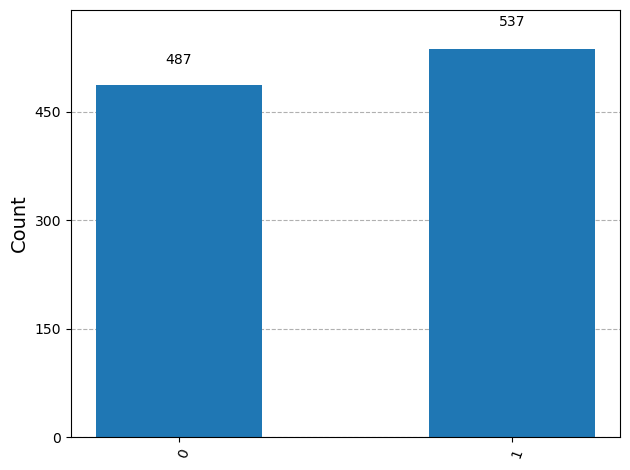

In [15]:
plot_histogram([counts])